1) What are 3 areas in industry where computer vision is currently being used?

Security, Autonomus driving, entertainment.

2. What is overfitting in machine learning?

When the model doesn't generalize and memorize the data it sees.

3) 3 ways to prevent overfitting:
- Dropout
- More data
- Regularization

In [100]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST

from torchmetrics import Accuracy, ConfusionMatrix

from tqdm.auto import tqdm
from timeit import default_timer as timer

import matplotlib.pyplot as plt

import random

from mlxtend.plotting import plot_confusion_matrix

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [70]:
training_set = MNIST(root="./data", train=True, download=True, transform=ToTensor())

test_set = MNIST(root="./data", train=False, download=True, transform=ToTensor())

In [71]:
BATCH_SIZE = 32

training_loader = DataLoader(training_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [72]:
class_names = training_set.classes
output_shape = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {output_shape}")

Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Number of classes: 10


In [73]:
image, label = training_set[0]
input_shape = image.shape[0]
image.shape, label, input_shape # -> [# number of channels, height, width] , label, #num of channels

(torch.Size([1, 28, 28]), 5, 1)

In [74]:
class minyCNN(nn.Module):
    
    def __init__(self, num_of_channels, output_shape, hidden_units = 32):
        
        super().__init__()
        
        # input: 1x28x28
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=num_of_channels, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 32x14x14
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units*2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 64x7x7
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units*2, out_channels=hidden_units*4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # 128x3x3
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*4*9, out_features=output_shape) 
        )
        
    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))

In [75]:
model = minyCNN(input_shape, output_shape).to(device)
model

minyCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=10, bias=True)
  )
)

In [76]:
loss_fn = nn.CrossEntropyLoss()
accuracy_fn = Accuracy(task="multiclass", num_classes=output_shape).to(device)
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [77]:
def training(model, loss_fn, accuracy_fn, optimizer, dataloader, device = device):
    
    train_loss, train_acc, total_count = 0, 0, 0
    
    model.train()
    
    for (X,y) in dataloader:
        
        bs = X.size(0)
        
        X, y = X.to(device), y.to(device)
        
        y_pred = model(X)
        
        loss = loss_fn(y_pred, y)
        
        train_loss += loss.item() * bs
        train_acc += accuracy_fn(y, y_pred.argmax(dim=1)) * bs
        
        optimizer.zero_grad()
        
        loss.backward()
        
        optimizer.step()
        
        total_count += bs
        
    return train_loss / total_count, train_acc / total_count
    



def testing(model, loss_fn, accuracy_fn, dataloader, device = device):
    
    test_loss, test_acc, total_count = 0, 0, 0
    
    model.eval()
    
    with torch.inference_mode():
        for (X, y) in dataloader:
            
            X, y = X.to(device), y.to(device)
            
            bs = X.size(0)
            
            y_pred = model(X)
            
            loss = loss_fn(y_pred, y)
            test_loss += loss.item() * bs
            test_acc += accuracy_fn(y, y_pred.argmax(dim=1)) * bs
            
            total_count += bs
            
    return test_loss / total_count, test_acc / total_count

In [78]:
EPOCHS = 3

start = timer()

for epoch in tqdm(range(1, EPOCHS+1)):
    
    print(f"Epoch: {epoch}\n----------")
    
    training_loss, training_acc = training(model, loss_fn, accuracy_fn, optimizer, training_loader)
    test_loss, test_acc = testing(model, loss_fn, accuracy_fn, test_loader)
    
    print(f"Train loss: {training_loss:.4f} | Training accuracy: {training_acc * 100:.3f}% | Test loss: {test_loss:.4f} | Test accuracy: {test_acc * 100:.3f}%")
    
end = timer()
time = end - start
print(f"Completed in {time}s")
    

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1
----------


 33%|███▎      | 1/3 [00:11<00:22, 11.47s/it]

Train loss: 0.1828 | Training accuracy: 94.198% | Test loss: 0.0422 | Test accuracy: 98.590%
Epoch: 2
----------


 67%|██████▋   | 2/3 [00:22<00:11, 11.44s/it]

Train loss: 0.0474 | Training accuracy: 98.560% | Test loss: 0.0283 | Test accuracy: 98.970%
Epoch: 3
----------


100%|██████████| 3/3 [00:34<00:00, 11.43s/it]

Train loss: 0.0340 | Training accuracy: 98.943% | Test loss: 0.0270 | Test accuracy: 99.120%
Completed in 34.3068101000008s


In [ ]:
def one_forward(model, test_samples, device=device):
    model.eval()

    pred_prob = []

    with torch.inference_mode():
        
        for sample in test_samples:
            
            sample = torch.unsqueeze(sample, dim=0).to(device)
            
            y_logits = model(sample)
            
            y_pred = torch.softmax(y_logits.squeeze(), dim=0)
            
            pred_prob.append(y_pred.cpu())
            
    pred_prob = torch.stack(pred_prob)
    return pred_prob.argmax(dim=1)

In [ ]:
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_set), k=9):
    test_samples.append(sample)
    test_labels.append(label)

pred_classes = one_forward(model, test_samples)

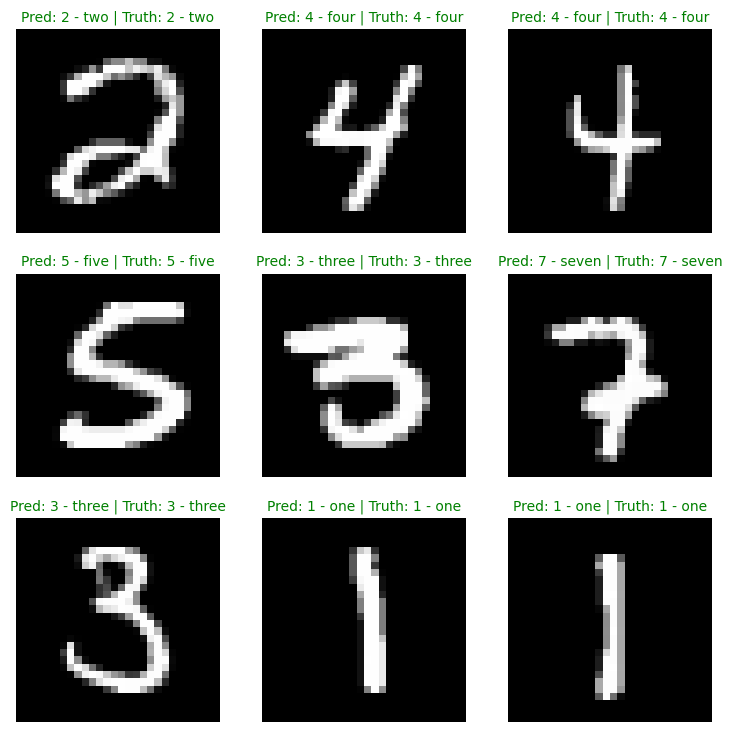

In [98]:
plt.figure(figsize=(9,9))
ncols = 3
nrows = 3

for i, sample in enumerate(test_samples):
    plt.subplot(nrows, ncols, i+1)
    plt.imshow(sample.squeeze(), cmap="gray")
    
    pred_label = class_names[pred_classes[i]]
    truth_label = class_names[test_labels[i]]
    
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"
    
    if pred_label == truth_label:
        plt.title(label=title_text, c="g", fontsize=10)
    else:
        plt.title(label=title_text, c="r", fontsize=10)
    plt.axis(False)

In [102]:
y_preds = []

model.eval()
with torch.inference_mode():
    
    for (X,y) in test_loader:
        
        X, y = X.to(device), y.to(device)
        
        y_pred = model(X)
        y_pred = torch.softmax(y_pred.squeeze(), dim=0).argmax(dim=1)
        y_preds.append(y_pred.cpu())
        
y_pred_tensor = torch.cat(y_preds)

(<Figure size 1000x700 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

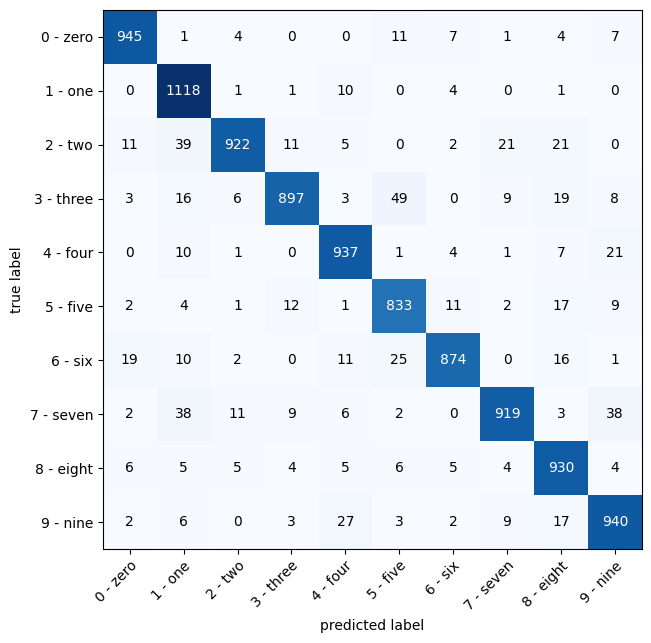

In [103]:
confmat = ConfusionMatrix(task="multiclass", num_classes=output_shape)
cofmat_tensor = confmat(preds=y_pred_tensor, target=test_set.targets)
plot_confusion_matrix(conf_mat=cofmat_tensor.numpy(), class_names=class_names, figsize=(10, 7))

TODO: For the user to paint a number and for the model to predict.